In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
csv_path = "data/sp500_5yr_with_sectors_weights.csv"

df = pd.read_csv(csv_path)

if "Weight" in df.columns:
    df = df.drop(columns=["Weight"])

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

# df.head()

In [3]:
# time periods for splitting

TRAIN_START = pd.Timestamp("2021-03-22")
TRAIN_END   = pd.Timestamp("2024-03-20")

VAL_START   = pd.Timestamp("2024-03-21")
VAL_END     = pd.Timestamp("2025-03-20")

UNSEEN_START = pd.Timestamp("2025-03-21")
UNSEEN_END   = pd.Timestamp("2026-03-20")

In [4]:
# keep only stocks that have data in all 3 periods to avoid unseen stock issues

train_symbols = set(df.loc[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END), "Symbol"].unique())
val_symbols = set(df.loc[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END), "Symbol"].unique())
unseen_symbols = set(df.loc[(df["Date"] >= UNSEEN_START) & (df["Date"] <= UNSEEN_END), "Symbol"].unique())

common_symbols = sorted(train_symbols & val_symbols & unseen_symbols)

df = df[df["Symbol"].isin(common_symbols)].copy()
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Common stocks:", df["Symbol"].nunique())

Common stocks: 499


In [5]:
# split into train/val/unseen

train_df = df[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END)].copy()
val_df = df[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END)].copy()
unseen_df = df[(df["Date"] >= UNSEEN_START) & (df["Date"] <= UNSEEN_END)].copy()

print("Train stocks:", train_df["Symbol"].nunique())
print("Val stocks:", val_df["Symbol"].nunique())
print("Unseen stocks:", unseen_df["Symbol"].nunique())

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Unseen shape:", unseen_df.shape)

Train stocks: 499
Val stocks: 499
Unseen stocks: 499
Train shape: (374800, 9)
Val shape: (124750, 9)
Unseen shape: (125248, 9)


In [6]:
# export and remove unseen

unseen_df.to_csv("unseen_holdout_raw.csv", index=False)

df = pd.concat([train_df, val_df], axis=0).sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Model dataframe shape:", df.shape)
print("Train + Val Date range:", df["Date"].min(), "to", df["Date"].max())

Model dataframe shape: (499550, 9)
Train + Val Date range: 2021-03-22 00:00:00 to 2025-03-20 00:00:00


In [ ]:
# feature engineering function

def engineer_features(panel_df, horizon=21):
    panel_df = panel_df.copy()
    g = panel_df.groupby("Symbol")

    # returns
    panel_df["log_return_1d"] = g["Close"].transform(lambda x: np.log(x / x.shift(1)))

    # volatility over the past 21 days (ending yesterday)
    panel_df["target"] = g["log_return_1d"].transform(
        lambda x: x.rolling(21).std().shift(1))

    # close lags
    panel_df["close_lag_1d"] = g["Close"].shift(1)
    panel_df["close_lag_5d"] = g["Close"].shift(5)
    panel_df["close_lag_21d"] = g["Close"].shift(21)

    # daily vol proxy in price space
    panel_df["daily_volatility"] = g["Close"].transform(lambda x: x.diff().abs())
    panel_df["daily_volatility_lag_1d"] = g["daily_volatility"].shift(1)
    panel_df["daily_volatility_lag_5d"] = g["daily_volatility"].shift(5)

    # return-based rolling volatility feature (same unit family as target)
    panel_df["return_volatility_5d"] = g["log_return_1d"].transform(
        lambda x: x.rolling(5).std().shift(1)
    )

    # volume lags
    panel_df["volume_lag_1d"] = g["Volume"].shift(1)
    panel_df["volume_lag_5d"] = g["Volume"].shift(5)
    panel_df["volume_lag_21d"] = g["Volume"].shift(21)

    return panel_df


In [8]:
# apply feature engineering to dev set

df = engineer_features(df)

feature_cols = [
    "close_lag_1d",
    "close_lag_5d",
    "close_lag_21d",
    "daily_volatility_lag_1d",
    "daily_volatility_lag_5d",
    "return_volatility_5d",
    "volume_lag_1d",
    "volume_lag_5d",
    "volume_lag_21d",
]

target_col = "target_volatility_21d"

df = df.dropna(subset=feature_cols + [target_col]).copy()

print(df.shape)
df.head()


(488572, 21)


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,log_return_1d,...,close_lag_1d,close_lag_5d,close_lag_21d,daily_volatility,daily_volatility_lag_1d,daily_volatility_lag_5d,return_volatility_5d,volume_lag_1d,volume_lag_5d,volume_lag_21d
22,2021-04-22,129.730502,131.114637,129.536920,130.214462,1732700,A,Agilent Technologies,Health Care,0.005217,...,129.536942,129.004578,117.887703,0.677521,1.326019,1.267960,0.009805,1173900.0,2121300.0,1338300.0
23,2021-04-23,130.253217,132.721405,130.185455,132.295517,1495200,A,Agilent Technologies,Health Care,0.015855,...,130.214462,130.262878,116.785934,2.081055,0.677521,1.258301,0.009165,1732700.0,4495400.0,1477500.0
24,2021-04-26,132.808491,133.408598,132.295479,132.934311,1287400,A,Agilent Technologies,Health Care,0.004817,...,132.295517,129.217545,117.810394,0.638794,2.081055,1.045334,0.010754,1495200.0,1071600.0,967300.0
25,2021-04-27,132.537460,133.031109,131.859918,132.101898,1752900,A,Agilent Technologies,Health Care,-0.006282,...,132.934311,128.210922,121.424896,0.832413,0.638794,1.006622,0.008775,1287400.0,1261200.0,1441900.0
26,2021-04-28,131.637318,132.130952,130.388705,130.475815,1603900,A,Agilent Technologies,Health Care,-0.012386,...,132.101898,129.536942,121.212296,1.626083,0.832413,1.326019,0.008191,1752900.0,1173900.0,1539700.0


In [9]:
df.feature_cols = feature_cols

/var/folders/sx/rlv33lyd2zs6vjp3khdjp3dc0000gn/T/ipykernel_40022/2979101694.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.feature_cols = feature_cols


In [10]:
# create train/val sets for modeling

train_feat = df[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END)].copy()
val_feat = df[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END)].copy()

print(train_feat.shape, val_feat.shape)
print(train_feat["Symbol"].nunique(), val_feat["Symbol"].nunique())

(363822, 21) (124750, 21)
499 499


In [11]:
LOOKBACK = 21

def make_sequences(panel_df, feature_cols, target_col, lookback=21):
    X_list = []
    y_list = []
    meta_list = []

    for symbol, g in panel_df.groupby("Symbol"):
        g = g.sort_values("Date").reset_index(drop=True)

        X_values = g[feature_cols].values
        y_values = g[target_col].values
        dates = g["Date"].values

        for t in range(lookback - 1, len(g)):
            X_window = X_values[t - lookback + 1 : t + 1]
            y_target = y_values[t]

            X_list.append(X_window)
            y_list.append(y_target)
            meta_list.append({
                "Symbol": symbol,
                "Date": dates[t]
            })

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta = pd.DataFrame(meta_list)

    return X, y, meta

In [12]:
# build sequences for train/val

X_train, y_train, meta_train = make_sequences(
    train_feat,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

X_val, y_val, meta_val = make_sequences(
    val_feat,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)

Train: (353842, 21, 9) (353842,)
Val: (114770, 21, 9) (114770,)


In [13]:
# scale features and target using train stats

n_features = X_train.shape[2]

train_2d = X_train.reshape(-1, n_features)
feature_means = train_2d.mean(axis=0)
feature_stds = train_2d.std(axis=0) + 1e-8

X_train_scaled = (X_train - feature_means) / feature_stds
X_val_scaled = (X_val - feature_means) / feature_stds

y_mean = y_train.mean()
y_std = y_train.std() + 1e-8

y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled = (y_val - y_mean) / y_std

In [14]:
# build model

keras.utils.set_random_seed(42)

model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, len(feature_cols))),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,921 (23.13 KB)

 Trainable params: 5,921 (23.13 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# train

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
5529/5529 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - loss: 0.0330 - mae: 0.0995 - val_loss: 0.0172 - val_mae: 0.0709
Epoch 2/100
5529/5529 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 0.0124 - mae: 0.0705 - val_loss: 0.0111 - val_mae: 0.0607
Epoch 3/100
5529/5529 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 0.0100 - mae: 0.0640 - val_loss: 0.0094 - val_mae: 0.0562
Epoch 4/100
5529/5529 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - loss: 0.0088 - mae: 0.0602 - val_loss: 0.0099 - val_mae: 0.0574
Epoch 5/100
5529/5529 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 0.0082 - mae: 0.0582 - val_loss: 0.0084 - val_mae: 0.0522
Epoch 6/100
5529/5529 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 0.0075 - mae: 0.0560 - val_loss: 0.0081 - val_mae: 0.0511
Epoch 7/100
5529/5529 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 0.0070 - mae: 0.0543 - val_loss: 0.0088 - val_mae: 0.0509
Epoch 8/100
5529/5529 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 0.0068 - mae: 0.0532 - val_loss: 0.0082 - val_mae: 0.0498
Epoch 9/100
5529/5529 ━━

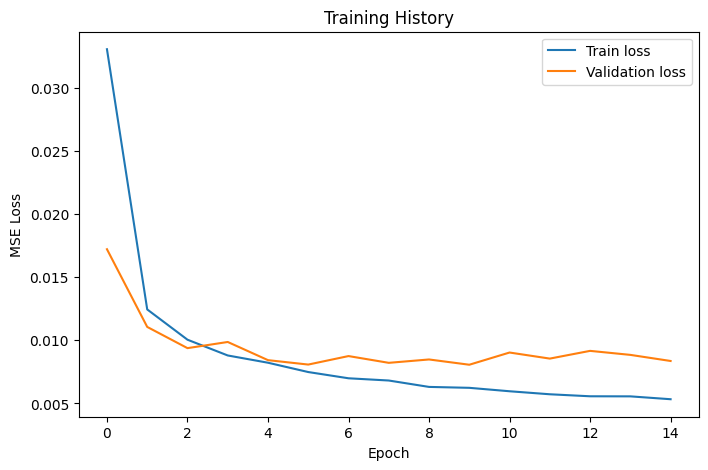

In [16]:
# plot training curve

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [17]:
# load unseen

unseen_df = pd.read_csv("data/sp500_unseen.csv")

unseen_df["Date"] = pd.to_datetime(unseen_df["Date"])
unseen_df = unseen_df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print(unseen_df["Date"].min(), unseen_df["Date"].max())
print(unseen_df.shape)
print("Stocks:", unseen_df["Symbol"].nunique())

2025-03-21 00:00:00 2026-03-20 00:00:00
(125248, 10)
Stocks: 499


In [18]:
# build scoring dataframe

history_df = val_df.copy()

scoring_df = pd.concat([history_df, unseen_df], axis=0)
scoring_df = scoring_df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print(scoring_df["Date"].min(), scoring_df["Date"].max())
print(scoring_df.shape)

2024-03-21 00:00:00 2026-03-20 00:00:00
(249998, 10)


In [19]:
# feature engineer

scoring_df = engineer_features(scoring_df)
scoring_df = scoring_df.dropna(subset=feature_cols + [target_col]).copy()

print(scoring_df.shape)
print(scoring_df["Date"].min(), scoring_df["Date"].max())

(239020, 22)
2024-04-23 00:00:00 2026-03-20 00:00:00


In [20]:
# build sequence

X_score, y_score, meta_score = make_sequences(
    scoring_df,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

print("X_score:", X_score.shape)
print("meta range:", meta_score["Date"].min(), meta_score["Date"].max())

X_score: (229040, 21, 9)
meta range: 2024-05-21 00:00:00 2026-03-20 00:00:00


In [21]:
# extract unseen portion

unseen_mask = (
    (meta_score["Date"] >= UNSEEN_START) &
    (meta_score["Date"] <= UNSEEN_END)
)

print("Unseen rows:", unseen_mask.sum())

X_unseen = X_score[unseen_mask]
y_unseen = y_score[unseen_mask]
meta_unseen = meta_score[unseen_mask].reset_index(drop=True)

print("X_unseen:", X_unseen.shape)
print("y_unseen:", y_unseen.shape)
print("meta_unseen:", meta_unseen.shape)

Unseen rows: 125248
X_unseen: (125248, 21, 9)
y_unseen: (125248,)
meta_unseen: (125248, 2)


In [22]:
# scale and predict on unseen

if len(X_unseen) == 0:
    raise ValueError("X_unseen is empty — something still wrong")

X_unseen_scaled = (X_unseen - feature_means) / feature_stds

y_unseen_pred_scaled = model.predict(X_unseen_scaled).flatten()
y_unseen_pred = y_unseen_pred_scaled * y_std + y_mean

3914/3914 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

unseen_rmse = np.sqrt(mean_squared_error(y_unseen, y_unseen_pred))
unseen_mae = mean_absolute_error(y_unseen, y_unseen_pred)
unseen_r2 = r2_score(y_unseen, y_unseen_pred)
unseen_corr = np.corrcoef(y_unseen, y_unseen_pred)[0, 1]

print("Unseen RMSE (LSTM):", unseen_rmse)
print("Unseen MAE (LSTM):", unseen_mae)
print("Unseen R^2 (LSTM):", unseen_r2)
print("Unseen Correlation (LSTM):", unseen_corr)


Unseen RMSE (LSTM): 0.0008476099043170041
Unseen MAE (LSTM): 0.0004966937121935189
Unseen R^2 (LSTM): 0.9938231110572815
Unseen Correlation (LSTM): 0.9969220764789318


In [24]:
# valid baselines on the same target scale

baseline_df = scoring_df[["Symbol", "Date", target_col]].copy()
baseline_df["baseline_persistence"] = baseline_df.groupby("Symbol")[target_col].shift(1)
baseline_df["baseline_rolling5"] = baseline_df.groupby("Symbol")[target_col].transform(
    lambda s: s.shift(1).rolling(5).mean()
)

baseline_unseen_df = meta_unseen.merge(
    baseline_df[["Symbol", "Date", "baseline_persistence", "baseline_rolling5"]],
    on=["Symbol", "Date"],
    how="left"
)

valid_mask = (
    baseline_unseen_df["baseline_persistence"].notna()
    & baseline_unseen_df["baseline_rolling5"].notna()
)

if valid_mask.sum() == 0:
    raise ValueError("No valid baseline rows after alignment")

# aligned eval arrays
keep_idx = valid_mask.values
y_eval = y_unseen[keep_idx]
y_pred_eval = y_unseen_pred[keep_idx]
meta_eval = meta_unseen.loc[keep_idx].reset_index(drop=True)

baseline_persistence_unseen = baseline_unseen_df.loc[valid_mask, "baseline_persistence"].to_numpy()
baseline_rolling5_unseen = baseline_unseen_df.loc[valid_mask, "baseline_rolling5"].to_numpy()

print("Eval rows after baseline alignment:", len(y_eval))


def metric_pack(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R^2": r2_score(y_true, y_pred),
        "Correlation": np.corrcoef(y_true, y_pred)[0, 1],
    }

lstm_metrics = metric_pack(y_eval, y_pred_eval)
persist_metrics = metric_pack(y_eval, baseline_persistence_unseen)
roll5_metrics = metric_pack(y_eval, baseline_rolling5_unseen)

print("Persistence Baseline RMSE:", persist_metrics["RMSE"])
print("Persistence Baseline MAE:", persist_metrics["MAE"])
print("Persistence Baseline R^2:", persist_metrics["R^2"])
print("Persistence Baseline Correlation:", persist_metrics["Correlation"])


Eval rows after baseline alignment: 125248
Persistence Baseline RMSE: 0.0021768851422255767
Persistence Baseline MAE: 0.0007896215245270236
Persistence Baseline R^2: 0.9592573355376959
Persistence Baseline Correlation: 0.979637037880009


In [25]:
metrics_df = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R^2", "Correlation"],
    "LSTM": [lstm_metrics["RMSE"], lstm_metrics["MAE"], lstm_metrics["R^2"], lstm_metrics["Correlation"]],
    "Persistence_Baseline": [persist_metrics["RMSE"], persist_metrics["MAE"], persist_metrics["R^2"], persist_metrics["Correlation"]],
    "Rolling5_Baseline": [roll5_metrics["RMSE"], roll5_metrics["MAE"], roll5_metrics["R^2"], roll5_metrics["Correlation"]],
})

metrics_df


,Metric,LSTM,Persistence_Baseline,Rolling5_Baseline
0,RMSE,0.000848,0.002177,0.003437
1,MAE,0.000497,0.000790,0.001694
2,R^2,0.993823,0.959257,0.898422
3,Correlation,0.996922,0.979637,0.948506


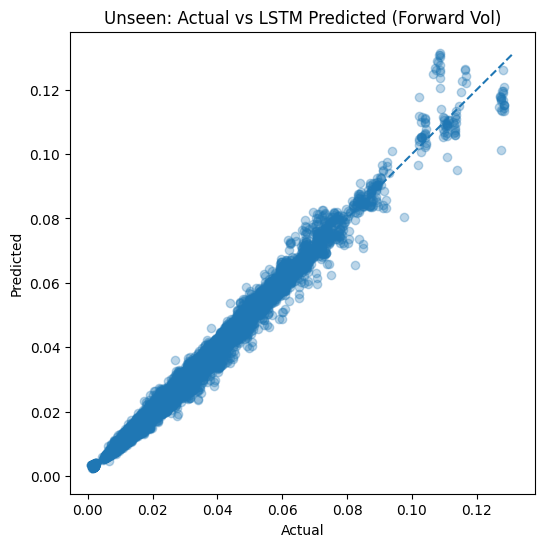

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_eval, y_pred_eval, alpha=0.3)

min_v = min(y_eval.min(), y_pred_eval.min())
max_v = max(y_eval.max(), y_pred_eval.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")

plt.title("Unseen: Actual vs LSTM Predicted (Forward Vol)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()


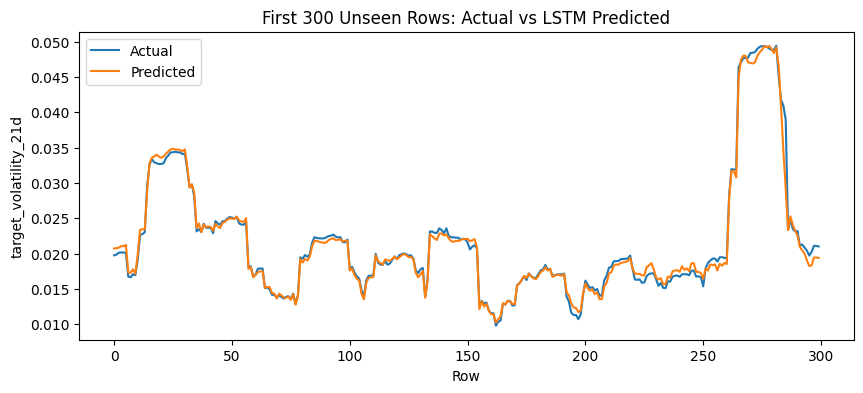

In [27]:
n_plot = min(300, len(y_eval))

plt.figure(figsize=(10, 4))
plt.plot(y_eval[:n_plot], label="Actual")
plt.plot(y_pred_eval[:n_plot], label="Predicted")
plt.title("First 300 Unseen Rows: Actual vs LSTM Predicted")
plt.xlabel("Row")
plt.ylabel(target_col)
plt.legend()
plt.show()


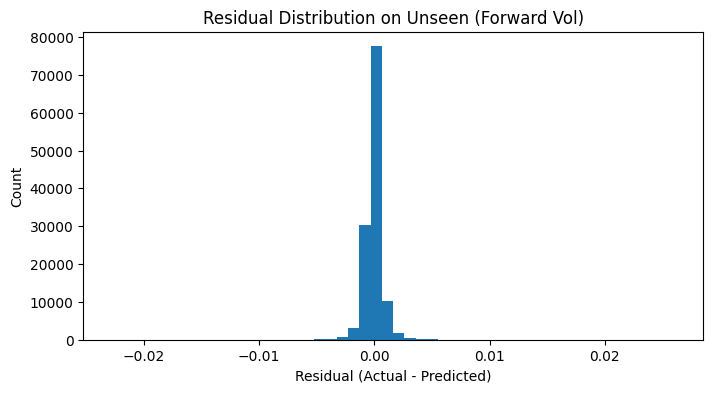

In [28]:
unseen_residuals = y_eval - y_pred_eval

plt.figure(figsize=(8, 4))
plt.hist(unseen_residuals, bins=50)
plt.title("Residual Distribution on Unseen (Forward Vol)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.show()


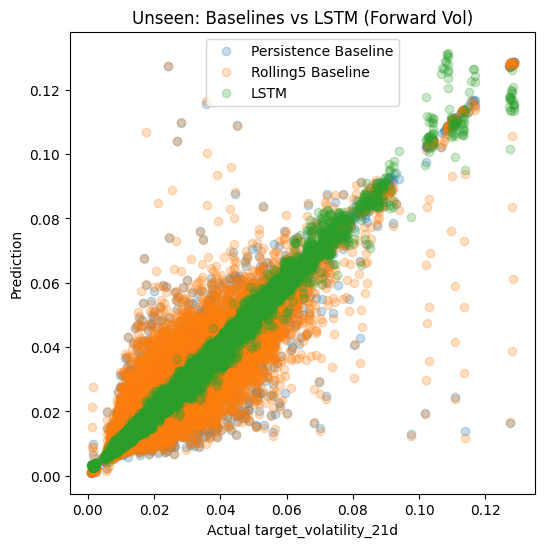

In [29]:
plt.figure(figsize=(6, 6))
plt.scatter(y_eval, baseline_persistence_unseen, alpha=0.25, label="Persistence Baseline")
plt.scatter(y_eval, baseline_rolling5_unseen, alpha=0.25, label="Rolling5 Baseline")
plt.scatter(y_eval, y_pred_eval, alpha=0.25, label="LSTM")
plt.title("Unseen: Baselines vs LSTM (Forward Vol)")
plt.xlabel(f"Actual {target_col}")
plt.ylabel("Prediction")
plt.legend()
plt.show()


In [30]:
# per stock

eval_df = meta_eval.copy()
eval_df["actual"] = y_eval
eval_df["predicted"] = y_pred_eval
eval_df["baseline_persistence_pred"] = baseline_persistence_unseen
eval_df["baseline_rolling5_pred"] = baseline_rolling5_unseen
eval_df["residual"] = eval_df["actual"] - eval_df["predicted"]

eval_df.head()


,Symbol,Date,actual,predicted,baseline_persistence_pred,baseline_rolling5_pred,residual
0,A,2025-03-21,0.019742,0.020714,0.020101,0.019706,-0.000972
1,A,2025-03-24,0.019853,0.020756,0.019742,0.020008,-0.000903
2,A,2025-03-25,0.020123,0.020832,0.019853,0.020006,-0.000710
3,A,2025-03-26,0.020154,0.021052,0.020123,0.020000,-0.000897
4,A,2025-03-27,0.020145,0.021033,0.020154,0.019995,-0.000887


In [31]:
def stock_metrics(group):
    y_true = group["actual"].values
    y_pred = group["predicted"].values
    y_base = group["baseline_persistence_pred"].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    base_rmse = np.sqrt(mean_squared_error(y_true, y_base))
    base_mae = mean_absolute_error(y_true, y_base)

    if len(y_true) > 1 and np.std(y_true) > 0 and np.std(y_pred) > 0:
        corr = np.corrcoef(y_true, y_pred)[0, 1]
    else:
        corr = np.nan

    if len(y_true) > 1 and np.std(y_true) > 0:
        r2 = r2_score(y_true, y_pred)
    else:
        r2 = np.nan

    return pd.Series({
        "n_obs": len(group),
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "corr": corr,
        "persistence_rmse": base_rmse,
        "persistence_mae": base_mae,
        "rmse_improvement_vs_persistence": base_rmse - rmse,
        "mae_improvement_vs_persistence": base_mae - mae
    })

per_stock_results = eval_df.groupby("Symbol").apply(stock_metrics).reset_index()
per_stock_results.head()


/var/folders/sx/rlv33lyd2zs6vjp3khdjp3dc0000gn/T/ipykernel_40022/1004184517.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_stock_results = eval_df.groupby("Symbol").apply(stock_metrics).reset_index()


,Symbol,n_obs,rmse,mae,r2,corr,persistence_rmse,persistence_mae,rmse_improvement_vs_persistence,mae_improvement_vs_persistence
0,A,251.0,0.000538,0.000435,0.989794,0.995089,0.001370,0.000711,0.000832,0.000276
1,AAPL,251.0,0.001157,0.000787,0.986921,0.995683,0.001799,0.000724,0.000642,-0.000063
2,ABBV,251.0,0.000418,0.000303,0.992306,0.996858,0.001207,0.000653,0.000790,0.000350
3,ABNB,251.0,0.000605,0.000439,0.994869,0.997797,0.001774,0.000778,0.001169,0.000339
4,ABT,251.0,0.000319,0.000242,0.996065,0.998907,0.001803,0.000587,0.001485,0.000345


In [32]:
per_stock_results[["rmse", "mae", "r2", "corr"]].describe()

,rmse,mae,r2,corr
count,499.000000,499.000000,499.000000,499.000000
mean,0.000695,0.000497,0.988781,0.995858
std,0.000486,0.000301,0.015186,0.005077
min,0.000235,0.000158,0.803135,0.921380
25%,0.000421,0.000319,0.987787,0.995414
50%,0.000547,0.000412,0.992767,0.997050
75%,0.000788,0.000572,0.995424,0.998106
max,0.004954,0.002663,0.998708,0.999375


In [33]:
print("Stocks beating persistence baseline on RMSE:",
      (per_stock_results["rmse_improvement_vs_persistence"] > 0).sum())

print("Stocks beating persistence baseline on MAE:",
      (per_stock_results["mae_improvement_vs_persistence"] > 0).sum())

print("Median per-stock correlation:",
      per_stock_results["corr"].median())

print("Median per-stock R^2:",
      per_stock_results["r2"].median())


Stocks beating persistence baseline on RMSE: 493
Stocks beating persistence baseline on MAE: 463
Median per-stock correlation: 0.9970500490098416
Median per-stock R^2: 0.9927666187286377


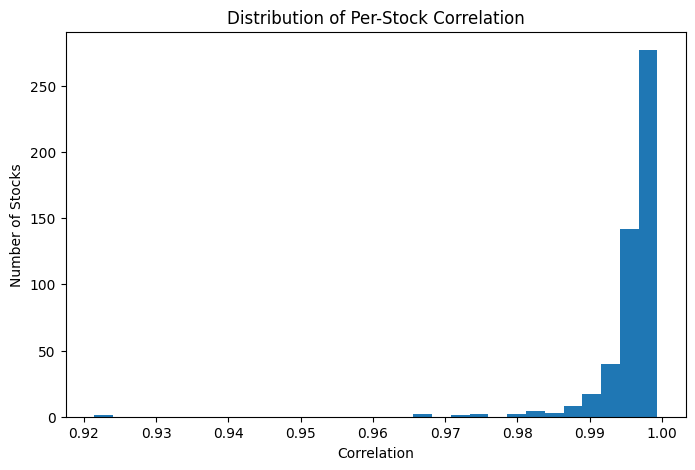

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(per_stock_results["corr"].dropna(), bins=30)
plt.title("Distribution of Per-Stock Correlation")
plt.xlabel("Correlation")
plt.ylabel("Number of Stocks")
plt.show()

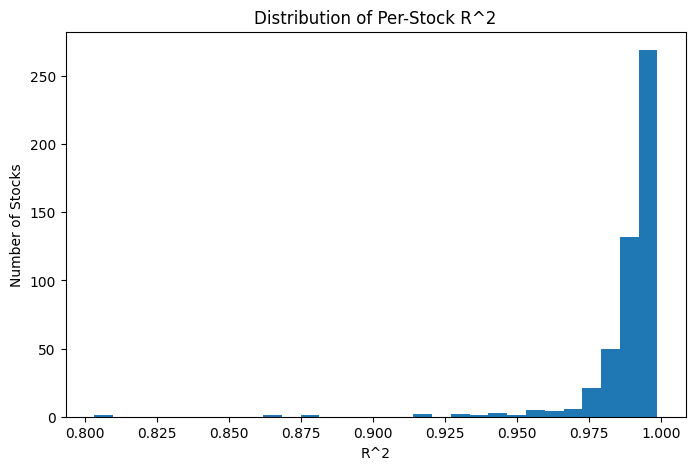

In [35]:
plt.figure(figsize=(8, 5))
plt.hist(per_stock_results["r2"].dropna(), bins=30)
plt.title("Distribution of Per-Stock R^2")
plt.xlabel("R^2")
plt.ylabel("Number of Stocks")
plt.show()

In [36]:
best_stocks = per_stock_results.sort_values("corr", ascending=False).head(10)
worst_stocks = per_stock_results.sort_values("corr", ascending=True).head(10)

print("Best stocks by correlation")
display(best_stocks)

print("Worst stocks by correlation")
display(worst_stocks)

Best stocks by correlation


,Symbol,n_obs,rmse,mae,r2,corr,persistence_rmse,persistence_mae,rmse_improvement_vs_persistence,mae_improvement_vs_persistence
91,CI,251.0,0.000351,0.000245,0.998708,0.999375,0.002817,0.000853,0.002466,0.000609
410,SPG,251.0,0.000335,0.000234,0.997994,0.999292,0.001381,0.000524,0.001046,0.000290
70,BSX,251.0,0.000457,0.000337,0.997885,0.999281,0.002723,0.000756,0.002267,0.000419
177,EXPD,251.0,0.000388,0.000293,0.998031,0.999202,0.002264,0.000780,0.001876,0.000487
195,FRT,251.0,0.000302,0.000254,0.996864,0.999196,0.001001,0.000455,0.000699,0.000201
488,WTW,251.0,0.000335,0.000240,0.997943,0.999172,0.001763,0.000640,0.001428,0.000400
170,ESS,251.0,0.000259,0.000186,0.997834,0.999141,0.001334,0.000599,0.001074,0.000413
368,PLD,251.0,0.000322,0.000254,0.997979,0.999139,0.001399,0.000631,0.001077,0.000377
157,EG,251.0,0.000259,0.000195,0.997951,0.999124,0.001664,0.000577,0.001405,0.000382
407,SNA,251.0,0.000252,0.000192,0.998129,0.999105,0.001330,0.000583,0.001078,0.000391


Worst stocks by correlation


,Symbol,n_obs,rmse,mae,r2,corr,persistence_rmse,persistence_mae,rmse_improvement_vs_persistence,mae_improvement_vs_persistence
341,NVR,251.0,0.001789,0.001463,0.803135,0.921380,0.001138,0.000615,-0.000650,-0.000848
180,F,251.0,0.002581,0.002120,0.866712,0.966924,0.001579,0.000724,-0.001002,-0.001396
50,AZO,251.0,0.000926,0.000702,0.933069,0.968049,0.001056,0.000551,0.000129,-0.000151
62,BKNG,251.0,0.001881,0.001178,0.941206,0.972634,0.001346,0.000636,-0.000535,-0.000542
95,CLX,251.0,0.000551,0.000416,0.940027,0.975580,0.000748,0.000487,0.000197,0.000071
188,FICO,251.0,0.002354,0.001598,0.952031,0.975737,0.003159,0.001360,0.000805,-0.000239
361,PFE,251.0,0.001508,0.001201,0.879093,0.979442,0.001221,0.000662,-0.000287,-0.000540
64,BLDR,251.0,0.000953,0.000671,0.961434,0.980548,0.001894,0.001085,0.000942,0.000414
244,INTC,251.0,0.003556,0.002663,0.918162,0.981274,0.003425,0.001611,-0.000131,-0.001052
14,AES,251.0,0.002330,0.001444,0.961621,0.981730,0.003484,0.001301,0.001153,-0.000143


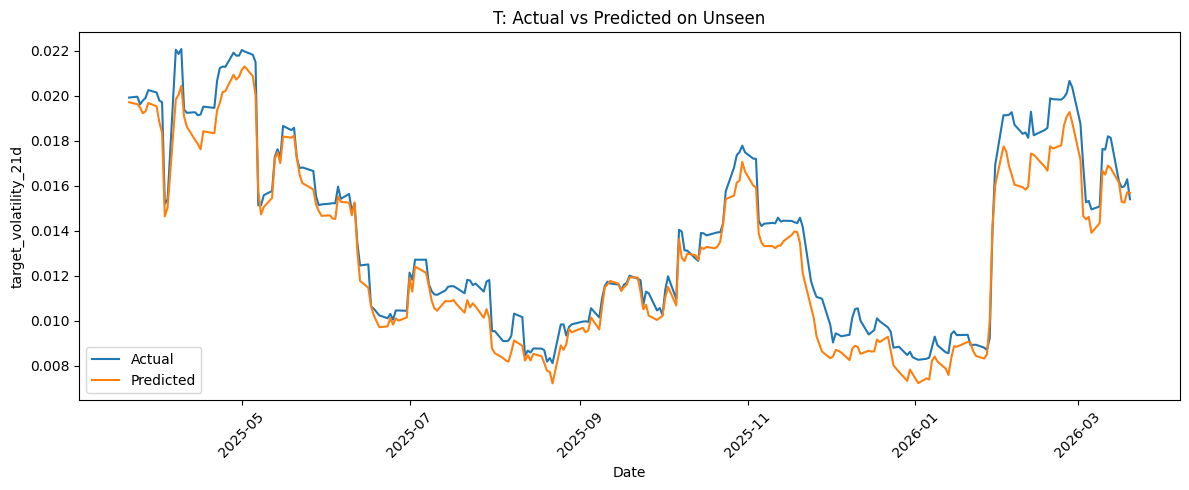

In [37]:
symbol_to_plot = "T"

stock_df = eval_df[eval_df["Symbol"] == symbol_to_plot].sort_values("Date")

plt.figure(figsize=(12, 5))
plt.plot(stock_df["Date"], stock_df["actual"], label="Actual")
plt.plot(stock_df["Date"], stock_df["predicted"], label="Predicted")
plt.title(f"{symbol_to_plot}: Actual vs Predicted on Unseen")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


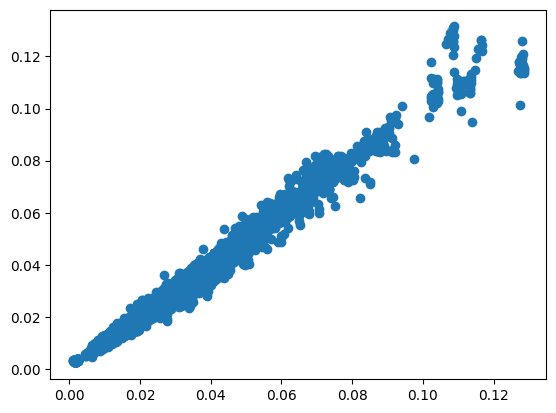

In [38]:
plt.scatter(y_unseen, y_unseen_pred)

In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

base_rmse = np.sqrt(mean_squared_error(y_eval, y_pred_eval))
base_mae = mean_absolute_error(y_eval, y_pred_eval)
base_r2 = r2_score(y_eval, y_pred_eval)

print("Base unseen RMSE (LSTM, aligned eval):", base_rmse)
print("Base unseen MAE (LSTM, aligned eval):", base_mae)
print("Base unseen R^2 (LSTM, aligned eval):", base_r2)


Base unseen RMSE (LSTM, aligned eval): 0.0008476099043170041
Base unseen MAE (LSTM, aligned eval): 0.0004966937121935189
Base unseen R^2 (LSTM, aligned eval): 0.9938231110572815


In [40]:
def permutation_importance_lstm(model, X_scaled, y_true, feature_cols, y_mean, y_std, n_repeats=5, random_state=42):
    rng = np.random.default_rng(random_state)
    results = []

    # baseline predictions
    y_pred_scaled = model.predict(X_scaled, verbose=0).flatten()
    y_pred = y_pred_scaled * y_std + y_mean

    baseline_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    baseline_mae = mean_absolute_error(y_true, y_pred)
    baseline_r2 = r2_score(y_true, y_pred)

    n_samples, lookback, n_features = X_scaled.shape

    for j, feature in enumerate(feature_cols):
        rmse_scores = []
        mae_scores = []
        r2_scores = []

        for _ in range(n_repeats):
            X_perm = X_scaled.copy()

            # shuffle this feature across samples, keeping time order inside each sample
            shuffled_idx = rng.permutation(n_samples)
            X_perm[:, :, j] = X_perm[shuffled_idx, :, j]

            y_perm_scaled = model.predict(X_perm, verbose=0).flatten()
            y_perm = y_perm_scaled * y_std + y_mean

            rmse_scores.append(np.sqrt(mean_squared_error(y_true, y_perm)))
            mae_scores.append(mean_absolute_error(y_true, y_perm))
            r2_scores.append(r2_score(y_true, y_perm))

        results.append({
            "feature": feature,
            "baseline_rmse": baseline_rmse,
            "perm_rmse_mean": np.mean(rmse_scores),
            "rmse_increase": np.mean(rmse_scores) - baseline_rmse,
            "baseline_mae": baseline_mae,
            "perm_mae_mean": np.mean(mae_scores),
            "mae_increase": np.mean(mae_scores) - baseline_mae,
            "baseline_r2": baseline_r2,
            "perm_r2_mean": np.mean(r2_scores),
            "r2_drop": baseline_r2 - np.mean(r2_scores),
        })

    return pd.DataFrame(results).sort_values("rmse_increase", ascending=False).reset_index(drop=True)

In [41]:
perm_importance_df = permutation_importance_lstm(
    model=model,
    X_scaled=X_unseen_scaled,
    y_true=y_unseen,
    feature_cols=feature_cols,
    y_mean=y_mean,
    y_std=y_std,
    n_repeats=5,
    random_state=42
)

perm_importance_df

,feature,baseline_rmse,perm_rmse_mean,rmse_increase,baseline_mae,perm_mae_mean,mae_increase,baseline_r2,perm_r2_mean,r2_drop
0,daily_volatility_lag_1d,0.000848,0.018823,0.017976,0.000497,0.013766,0.013269,0.993823,-2.046315,3.040138
1,close_lag_1d,0.000848,0.009638,0.008790,0.000497,0.007306,0.006809,0.993823,0.201397,0.792426
2,return_volatility_5d,0.000848,0.006882,0.006035,0.000497,0.004039,0.003542,0.993823,0.592761,0.401063
3,close_lag_5d,0.000848,0.005753,0.004905,0.000497,0.004141,0.003644,0.993823,0.715473,0.278350
4,close_lag_21d,0.000848,0.003778,0.002931,0.000497,0.001812,0.001315,0.993823,0.877252,0.116571
5,daily_volatility_lag_5d,0.000848,0.003303,0.002456,0.000497,0.001350,0.000853,0.993823,0.906171,0.087652
6,volume_lag_1d,0.000848,0.001164,0.000316,0.000497,0.000626,0.000129,0.993823,0.988353,0.005470
7,volume_lag_5d,0.000848,0.001160,0.000312,0.000497,0.000618,0.000121,0.993823,0.988437,0.005386
8,volume_lag_21d,0.000848,0.000915,0.000067,0.000497,0.000528,0.000031,0.993823,0.992809,0.001014


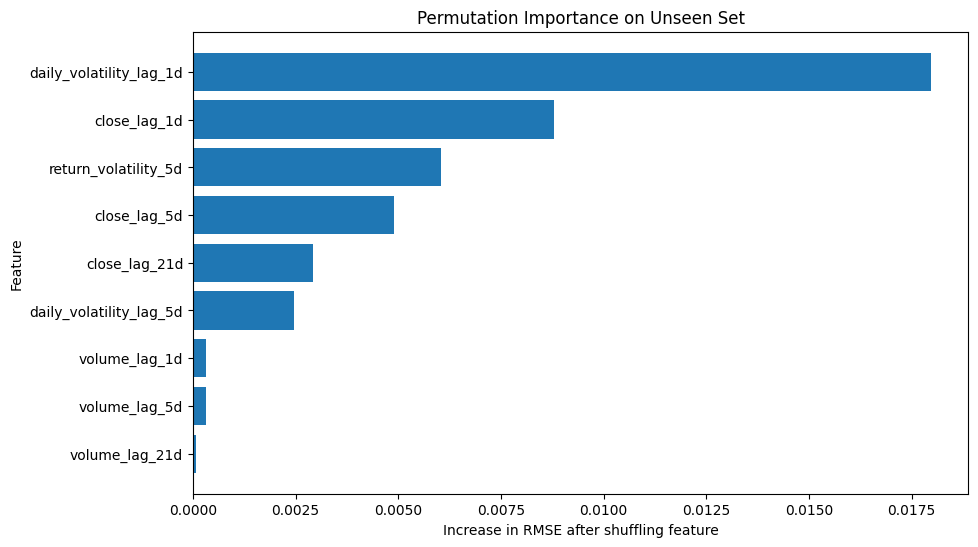

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(perm_importance_df["feature"], perm_importance_df["rmse_increase"])
plt.gca().invert_yaxis()
plt.title("Permutation Importance on Unseen Set")
plt.xlabel("Increase in RMSE after shuffling feature")
plt.ylabel("Feature")
plt.show()

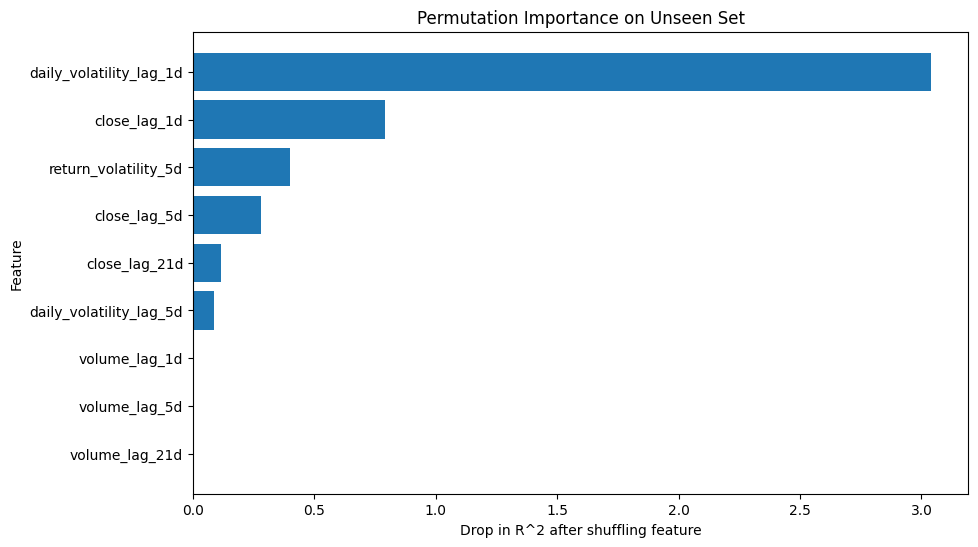

In [43]:
plt.figure(figsize=(10, 6))
plt.barh(perm_importance_df["feature"], perm_importance_df["r2_drop"])
plt.gca().invert_yaxis()
plt.title("Permutation Importance on Unseen Set")
plt.xlabel("Drop in R^2 after shuffling feature")
plt.ylabel("Feature")
plt.show()